# PBL3

## import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.feature_selection import f_classif
from sklearn.cluster import KMeans
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

### 한글 폰트 (필요 시)

In [6]:
# plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## ========================================
## 1. 데이터 로드
## ========================================

In [7]:
print("1. 데이터 로드 중...")
df_train_full = pd.read_parquet('./train.parquet')
df_test_full = pd.read_parquet('./test.parquet')

print(f"Train 전체: {df_train_full.shape}")
print(f"Test 전체: {df_test_full.shape}")

# 시각화용 샘플
df_train = df_train_full.sample(100000, random_state=42)
df_test = df_test_full.sample(min(50000, len(df_test_full)), random_state=42)

target_col = 'clicked'
id_col = 'ID'

has_id = id_col in df_train.columns
print(f"ID 컬럼 존재: {has_id}")
has_target_test = target_col in df_test.columns
print(f"Test에 clicked: {has_target_test}")

1. 데이터 로드 중...
Train 전체: (10704179, 119)
Test 전체: (1527298, 119)
ID 컬럼 존재: False
Test에 clicked: False


## ========================================
## 2. 결측치 처리
## ========================================

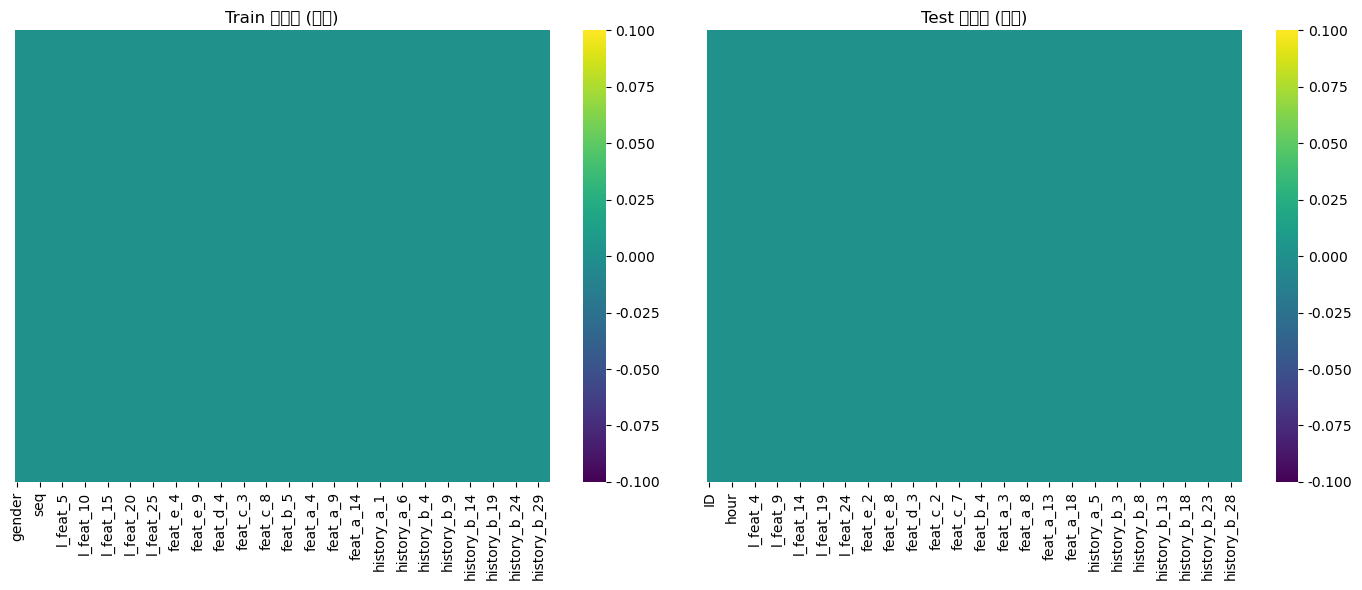

In [9]:
def preprocess_missing(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    missing_train = train_df.isnull().mean()
    high_missing = missing_train[missing_train >= 0.05].index.tolist()
    high_missing = [c for c in high_missing if c != target_col and (not has_id or c != id_col)]
    train_df = train_df.drop(columns=high_missing)
    test_df = test_df.drop(columns=[c for c in high_missing if c in test_df.columns])

    num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]
    cat_cols = train_df.select_dtypes(include='object').columns.tolist()
    if has_id:
        cat_cols = [c for c in cat_cols if c != id_col]

    train_df = train_df.dropna(subset=num_cols)

    if cat_cols:
        imputer = SimpleImputer(strategy='most_frequent')
        train_df[cat_cols] = imputer.fit_transform(train_df[cat_cols])
        test_df[cat_cols] = imputer.transform(test_df[cat_cols])

    return train_df, test_df, num_cols, cat_cols

df_train, df_test, num_cols, cat_cols = preprocess_missing(df_train, df_test)

# 시각화: 결측치
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.heatmap(df_train.sample(1000).isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Train 결측치 (샘플)')
plt.subplot(1, 2, 2)
sns.heatmap(df_test.sample(1000).isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Test 결측치 (샘플)')
plt.tight_layout()
plt.savefig('01_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## ========================================
## 3. 이상치 제거 (train만)
## ========================================

Train 이상치: 49705개


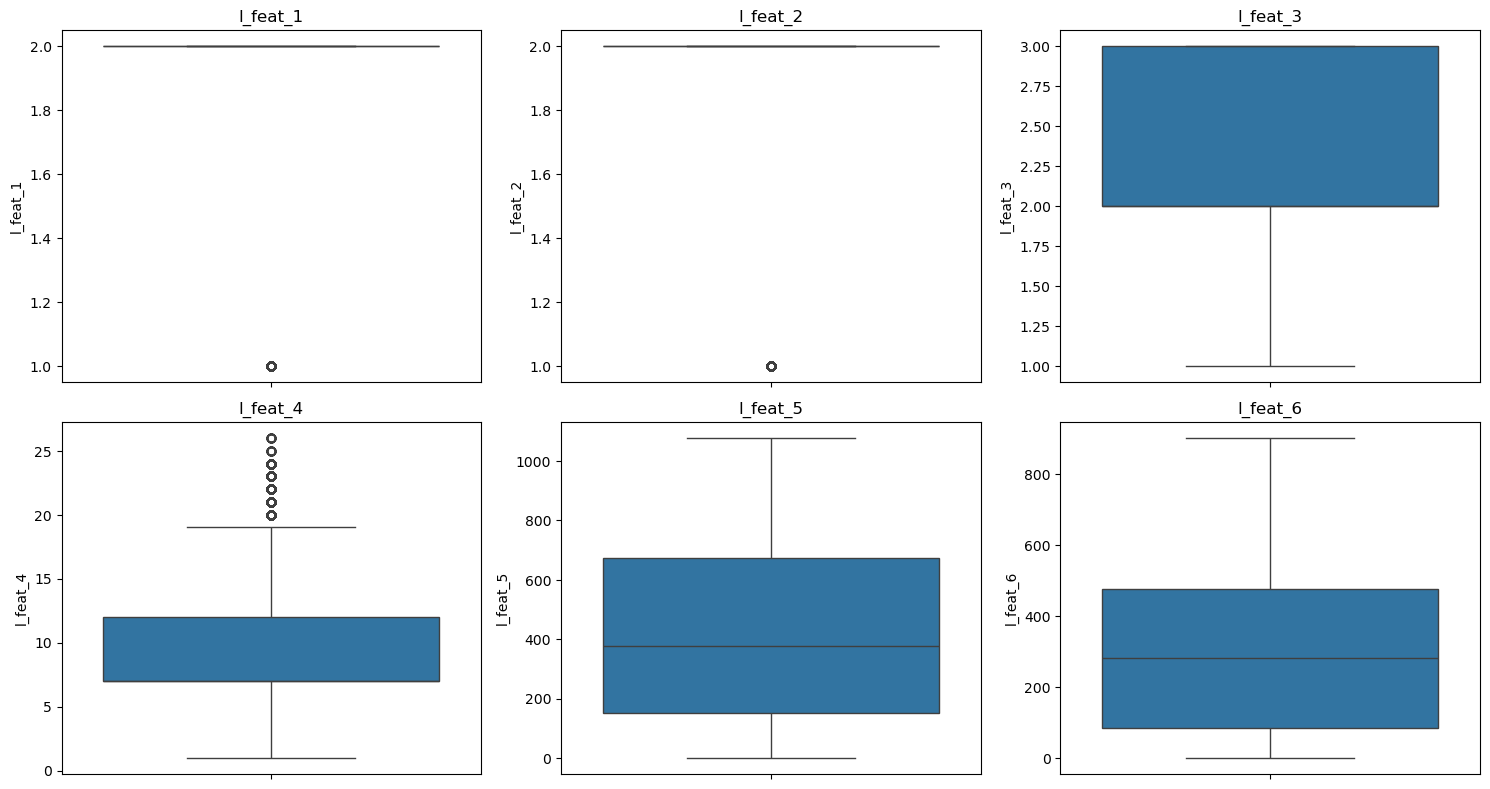

In [10]:
if num_cols:
    z = np.abs(stats.zscore(df_train[num_cols]))
    outliers = (z > 3).any(axis=1)
    print(f"Train 이상치: {outliers.sum()}개")
    df_train = df_train[~outliers]

    plt.figure(figsize=(15, 8))
    for i, col in enumerate(num_cols[:6], 1):
        plt.subplot(2, 3, i)
        sns.boxplot(y=df_train[col])
        plt.title(f'{col}')
    plt.tight_layout()
    plt.savefig('02_outliers_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

## ========================================
## 4. 스케일링
## ========================================

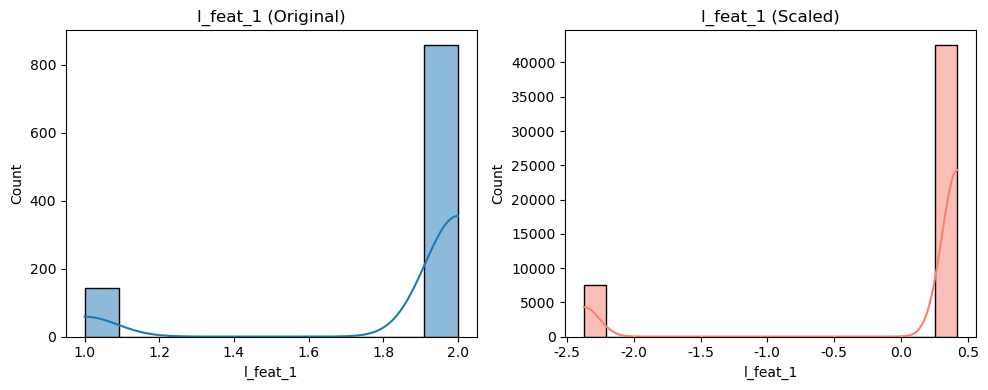

In [11]:
scaler = StandardScaler()
if num_cols:
    df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
    df_test[num_cols] = scaler.transform(df_test[num_cols])

    col = num_cols[0]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_train_full[col].dropna().sample(1000), kde=True)
    plt.title(f'{col} (Original)')
    plt.subplot(1, 2, 2)
    sns.histplot(df_train[col], kde=True, color='salmon')
    plt.title(f'{col} (Scaled)')
    plt.tight_layout()
    plt.savefig('03_scaling.png', dpi=150, bbox_inches='tight')
    plt.show()

## ========================================
## 5. 클래스 불균형 조정 (train만)
## ========================================

Train clicked 분포:
clicked
0    0.982683
1    0.017317
Name: proportion, dtype: float64


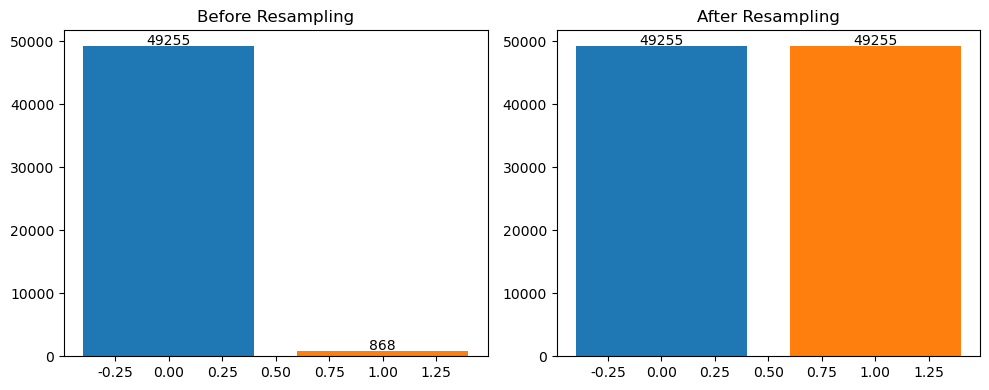

In [12]:
print(f"Train clicked 분포:\n{df_train[target_col].value_counts(normalize=True)}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
counts_before = df_train[target_col].value_counts()
plt.bar(counts_before.index, counts_before.values, color=['#1f77b4', '#ff7f0e'])
plt.title('Before Resampling')
for i, v in enumerate(counts_before.values):
    plt.text(i, v + 100, str(v), ha='center')

df_major = df_train[df_train[target_col] == 0]
df_minor = df_train[df_train[target_col] == 1]
df_minor_up = resample(df_minor, replace=True, n_samples=len(df_major), random_state=42)
df_balanced = pd.concat([df_major, df_minor_up])

plt.subplot(1, 2, 2)
counts_after = df_balanced[target_col].value_counts()
plt.bar(counts_after.index, counts_after.values, color=['#1f77b4', '#ff7f0e'])
plt.title('After Resampling')
for i, v in enumerate(counts_after.values):
    plt.text(i, v + 100, str(v), ha='center')

plt.tight_layout()
plt.savefig('04_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## ========================================
## 6. 피처 엔지니어링 (최신 버전 + 오류 방지)
## ========================================

In [13]:
from sklearn.impute import SimpleImputer

def add_features(df, is_train=True, cluster_imputer=None):
    df = df.copy()
    
    # 1. is_weekend
    if 'day_of_week' in df.columns:
        df['is_weekend'] = df['day_of_week'].astype(str).str.contains('5|6', na=False).astype(int)
    
    # 2. seq 처리
    if 'seq' in df.columns:
        df['seq_length'] = df['seq'].str.split(',').str.len().fillna(0)
        df['seq_unique'] = df['seq'].str.split(',').apply(lambda x: len(set(x)) if isinstance(x, str) else 0)
        df['seq_diversity'] = df['seq_unique'] / (df['seq_length'] + 1e-8)
    
    # 3. 클러스터링 (안정성 우선)
    cluster_cols = [c for c in num_cols if c in df.columns]
    if cluster_cols and len(df) > 100:
        try:
            if is_train:
                cluster_imputer = SimpleImputer(strategy='mean')
                df_cluster = cluster_imputer.fit_transform(df[cluster_cols])
            else:
                if cluster_imputer is None:
                    print("클러스터링 건너뜀 (test용 imputer 없음)")
                    return df, None
                df_cluster = cluster_imputer.transform(df[cluster_cols])
            
            kmeans = KMeans(n_clusters=min(6, max(2, len(df)//500)), random_state=42, n_init=10)
            df['cluster'] = kmeans.fit_predict(df_cluster) if is_train else kmeans.predict(df_cluster)
            df = pd.get_dummies(df, columns=['cluster'], prefix='cluster')
        except Exception as e:
            print(f"클러스터링 실패 (건너뜀): {e}")
    
    return df, cluster_imputer

# 실행 (정확한 호출)
df_balanced, cluster_imputer = add_features(df_balanced, is_train=True)
df_test, _ = add_features(df_test, is_train=False, cluster_imputer=cluster_imputer)

# num_cols, cat_cols 업데이트
num_cols = [c for c in df_balanced.columns if np.issubdtype(df_balanced[c].dtype, np.number) and c != target_col]
cat_cols = [c for c in df_balanced.columns if c not in num_cols and c != target_col and (not has_id or c != id_col)]

클러스터링 실패 (건너뜀): This KMeans instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


## ========================================
## 7. p-value 기반 피처 선택
## ========================================

In [14]:
y = df_balanced[target_col]
selected_cats = []
pvals_num = []

if num_cols:
    X_num = df_balanced[num_cols].fillna(0)
    _, p_num = f_classif(X_num, y)
    pvals_num = p_num.tolist()

for cat in cat_cols[:15]:
    try:
        enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore', max_categories=10)
        X_cat = enc.fit_transform(df_balanced[[cat]])
        if X_cat.shape[1] <= 1: continue
        X_cat = sm.add_constant(X_cat)
        model = sm.Logit(y, X_cat).fit_regularized(method='l1', alpha=1e-6, maxiter=200, trim_mode='size', disp=False)
        pvals = model.pvalues[1:]
        if (pvals < 0.05).any():
            selected_cats.append(cat)
    except: continue

p_results = pd.DataFrame({
    'Feature': num_cols + selected_cats,
    'P-value': pvals_num + [0.001]*len(selected_cats),
    'Type': ['Numeric']*len(num_cols) + ['Categorical']*len(selected_cats)
}).sort_values('P-value')

p_results['-log10(p)'] = -np.log10(p_results['P-value'].clip(1e-10))
p_results['Significant'] = p_results['P-value'] < 0.05

print(f"\n유의미한 피처: {p_results['Significant'].sum()}개")


유의미한 피처: 91개


## ========================================
## 8. p-value 시각화
## ========================================

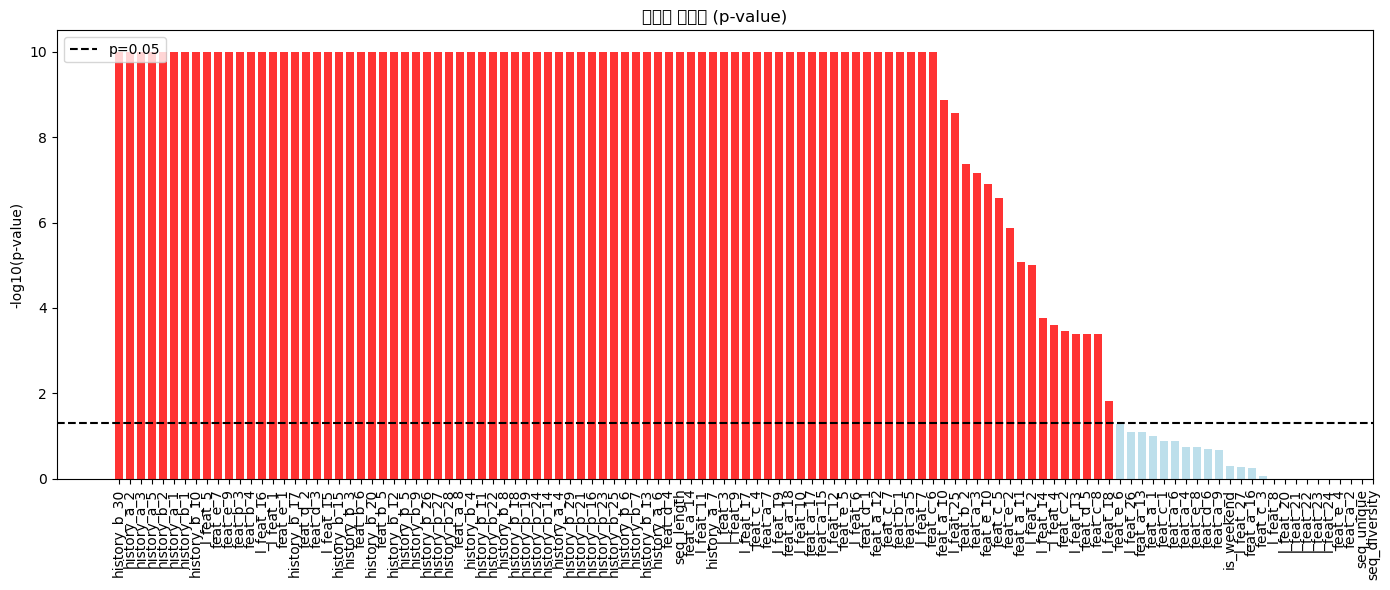

In [15]:
plt.figure(figsize=(14, 6))
colors = p_results['Significant'].map({True: 'red', False: 'lightblue'})
plt.bar(range(len(p_results)), p_results['-log10(p)'], color=colors, alpha=0.8)
plt.xticks(range(len(p_results)), p_results['Feature'], rotation=90)
plt.axhline(-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.ylabel('-log10(p-value)')
plt.title('피처별 영향력 (p-value)')
plt.legend()
plt.tight_layout()
plt.savefig('05_pvalue_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## ========================================
## 9. 최종 요약
## ========================================

In [16]:
final_features = p_results[p_results['Significant']]['Feature'].tolist()

summary = pd.DataFrame({
    'Step': ['데이터 로드', '결측치 처리', '이상치 제거', '스케일링', '클래스 균형', '피처 엔지니어링', '피처 선택'],
    'Method': [
        'train.parquet + test.parquet',
        '5% 이상 drop + 최빈값',
        'Z-score >3 제거',
        'StandardScaler',
        '오버샘플링 (train만)',
        'is_weekend, seq, 클러스터링 (안정성 우선)',
        f'p<0.05 → {len(final_features)}개'
    ],
    'Impact': [
        f'Train: {df_train_full.shape}, Test: {df_test_full.shape}',
        '결측 0%',
        f'{outliers.sum() if "outliers" in locals() else 0}개 제거',
        '정규화 완료',
        '50:50 균형',
        '신규 피처 추가',
        f'{len(p_results)} → {len(final_features)}'
    ]
})

print("\n=== PBL-3 기반 전처리 요약 ===")
print(summary.to_string(index=False))

summary.to_csv('preprocess_summary.csv', index=False)
p_results.to_csv('pvalue_results.csv', index=False)

print("\n모든 그래프 및 결과 저장 완료!")
print("발표 자료: 01~05 PNG + CSV 2개")


=== PBL-3 기반 전처리 요약 ===
    Step                          Method                                       Impact
  데이터 로드    train.parquet + test.parquet Train: (10704179, 119), Test: (1527298, 119)
  결측치 처리                5% 이상 drop + 최빈값                                        결측 0%
  이상치 제거                   Z-score >3 제거                                    49705개 제거
    스케일링                  StandardScaler                                       정규화 완료
  클래스 균형                  오버샘플링 (train만)                                     50:50 균형
피처 엔지니어링 is_weekend, seq, 클러스터링 (안정성 우선)                                     신규 피처 추가
   피처 선택                    p<0.05 → 91개                                     115 → 91

모든 그래프 및 결과 저장 완료!
발표 자료: 01~05 PNG + CSV 2개
